<a href="https://colab.research.google.com/github/vvalenzuela-23/Estadistica/blob/main/Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROBLEMA: PRODUCCIÓN DE LECHE CON SUPLEMENTOS ALIMENTICIOS

DATOS ORIGINALES:
       S1  S2  S3
Obs 1  22  27  25
Obs 2  20  29  23
Obs 3  24  28  26
Obs 4  21  30  24
Obs 5  23  26  22


Media Global: 24.6667 litros

Medias por Observación:
  Obs 1.......  24.6667 litros
  Obs 2.......  24.0000 litros
  Obs 3.......  26.0000 litros
  Obs 4.......  25.0000 litros
  Obs 5.......  23.6667 litros

Medias por Suplemento:
  S1.............  22.0000 litros
  S2.............  28.0000 litros
  S3.............  24.0000 litros


TABLA ANOVA DE DOS VÍAS
Fuente de Variación            SC     gl           CM            F      Valor-p    F crítico
----------------------------------------------------------------------------------------------------
Observaciones             10.0000      4       2.5000       1.0000     0.460905       7.0061
Suplementos               93.3333      2      46.6667      18.6667     0.000970       8.6491
Error                     20.0000      8       2.5000
Total            

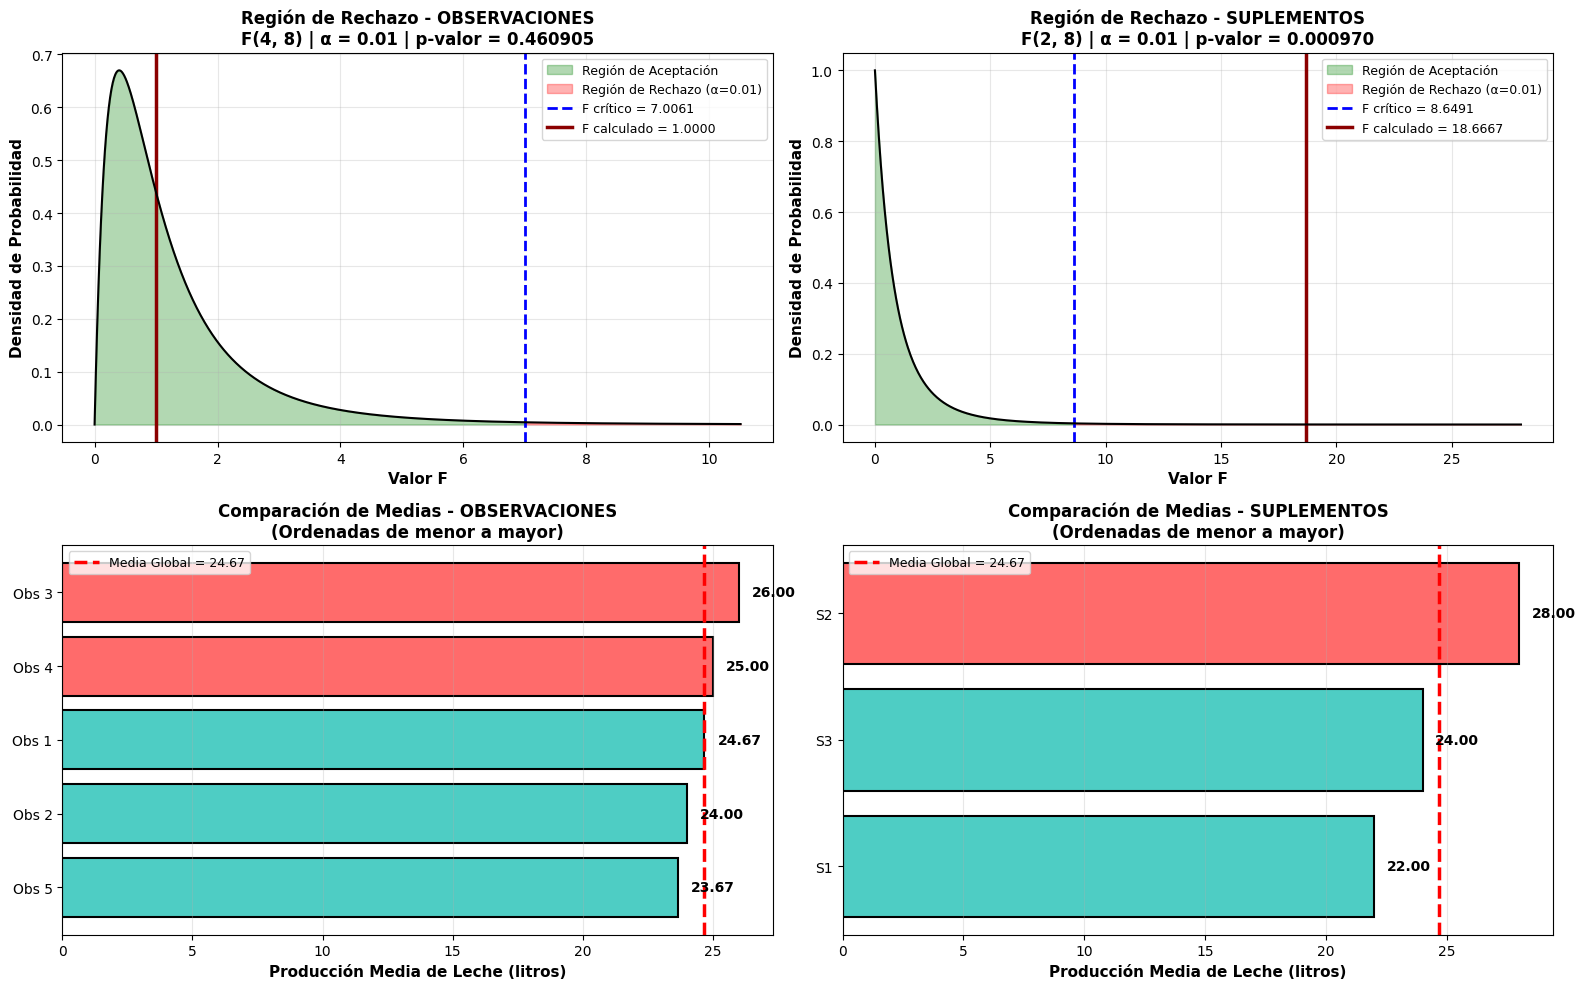

✓ Gráfico guardado como 'produccion_leche_tukey_matrices.png'


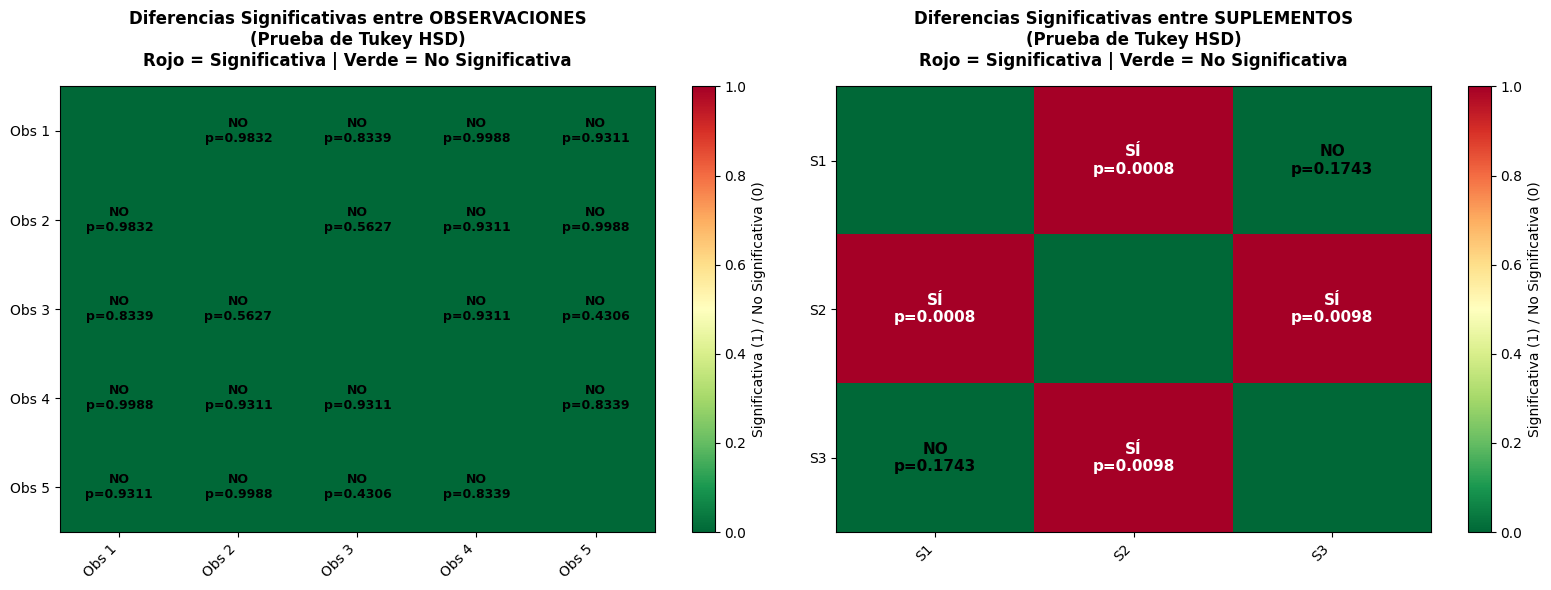


ANÁLISIS COMPLETO FINALIZADO

CONCLUSIÓN FINAL:
--------------------------------------------------------------------------------
✓ Se encontraron diferencias significativas en la producción de leche.
  Las diferencias se deben a los suplementos, no a las observaciones.


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from itertools import combinations

# Configuración para mejor visualización
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================
# Datos del problema - Producción de leche con suplementos
observaciones = ['Obs 1', 'Obs 2', 'Obs 3', 'Obs 4', 'Obs 5']
suplementos = ['S1', 'S2', 'S3']

# Matriz de producción de leche
datos = np.array([
    [22, 27, 25],  # Obs 1
    [20, 29, 23],  # Obs 2
    [24, 28, 26],  # Obs 3
    [21, 30, 24],  # Obs 4
    [23, 26, 22]   # Obs 5
])

# Crear DataFrame para mejor visualización
df = pd.DataFrame(datos, index=observaciones, columns=suplementos)
print("="*80)
print("PROBLEMA: PRODUCCIÓN DE LECHE CON SUPLEMENTOS ALIMENTICIOS")
print("="*80)
print("\nDATOS ORIGINALES:")
print(df)
print("\n" + "="*80 + "\n")

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

n_observaciones = len(observaciones)
n_suplementos = len(suplementos)
n_total = n_observaciones * n_suplementos

# Calcular medias
media_global = np.mean(datos)
medias_observaciones = np.mean(datos, axis=1)
medias_suplementos = np.mean(datos, axis=0)

print(f"Media Global: {media_global:.4f} litros")
print(f"\nMedias por Observación:")
for i, obs in enumerate(observaciones):
    print(f"  {obs:.<12} {medias_observaciones[i]:>8.4f} litros")
print(f"\nMedias por Suplemento:")
for i, sup in enumerate(suplementos):
    print(f"  {sup:.<15} {medias_suplementos[i]:>8.4f} litros")
print("\n" + "="*80 + "\n")

# ============================================================================
# ANOVA DE DOS VÍAS SIN INTERACCIÓN
# ============================================================================

# Suma de cuadrados total (SCT)
SCT = np.sum((datos - media_global)**2)

# Suma de cuadrados de observaciones (SCO)
SCO = n_suplementos * np.sum((medias_observaciones - media_global)**2)

# Suma de cuadrados de suplementos (SCS)
SCS = n_observaciones * np.sum((medias_suplementos - media_global)**2)

# Suma de cuadrados del error (SCE)
SCE = SCT - SCO - SCS

# Grados de libertad
gl_observaciones = n_observaciones - 1
gl_suplementos = n_suplementos - 1
gl_error = (n_observaciones - 1) * (n_suplementos - 1)
gl_total = n_total - 1

# Cuadrados medios
CMO = SCO / gl_observaciones
CMS = SCS / gl_suplementos
CME = SCE / gl_error

# Estadísticos F
F_observaciones = CMO / CME
F_suplementos = CMS / CME

# Definir alpha
alpha = 0.01

# Valores p
p_observaciones = 1 - stats.f.cdf(F_observaciones, gl_observaciones, gl_error)
p_suplementos = 1 - stats.f.cdf(F_suplementos, gl_suplementos, gl_error)

# Valores críticos F para α = 0.01
F_crit_observaciones = stats.f.ppf(1 - alpha, gl_observaciones, gl_error)
F_crit_suplementos = stats.f.ppf(1 - alpha, gl_suplementos, gl_error)

# ============================================================================
# TABLA ANOVA
# ============================================================================
print("TABLA ANOVA DE DOS VÍAS")
print("="*100)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12} {'F crítico':>12}")
print("-"*100)
print(f"{'Observaciones':<20} {SCO:>12.4f} {gl_observaciones:>6} {CMO:>12.4f} {F_observaciones:>12.4f} {p_observaciones:>12.6f} {F_crit_observaciones:>12.4f}")
print(f"{'Suplementos':<20} {SCS:>12.4f} {gl_suplementos:>6} {CMS:>12.4f} {F_suplementos:>12.4f} {p_suplementos:>12.6f} {F_crit_suplementos:>12.4f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_error:>6} {CME:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_total:>6}")
print("="*100)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================
print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

print(f"\n1. EFECTO DE LAS OBSERVACIONES (FILAS):")
print(f"   F calculado = {F_observaciones:.4f}")
print(f"   F crítico = {F_crit_observaciones:.4f}")
print(f"   Valor-p = {p_observaciones:.6f}")
if p_observaciones < alpha:
    print(f"   ✓ Hay diferencia significativa entre las observaciones (p < {alpha})")
    print(f"   → La producción de leche varía significativamente entre las observaciones.")
else:
    print(f"   ✗ No hay diferencia significativa entre las observaciones (p ≥ {alpha})")
    print(f"   → La producción de leche es similar en todas las observaciones.")

print(f"\n2. EFECTO DE LOS SUPLEMENTOS (COLUMNAS):")
print(f"   F calculado = {F_suplementos:.4f}")
print(f"   F crítico = {F_crit_suplementos:.4f}")
print(f"   Valor-p = {p_suplementos:.6f}")
if p_suplementos < alpha:
    print(f"   ✓ Hay diferencia significativa entre los suplementos (p < {alpha})")
    print(f"   → Los suplementos tienen un efecto diferente en la producción de leche.")
else:
    print(f"   ✗ No hay diferencia significativa entre los suplementos (p ≥ {alpha})")
    print(f"   → Los suplementos tienen un efecto similar en la producción de leche.")

# ============================================================================
# PRUEBA DE TUKEY (HSD - Honestly Significant Difference)
# ============================================================================

print("\n" + "="*80)
print("PRUEBA DE TUKEY (HSD) - COMPARACIONES MÚLTIPLES")
print("="*80)

# --------------------------------------------------------------------------
# COMPARACIONES PARA OBSERVACIONES
# --------------------------------------------------------------------------
print("\n" + "-"*80)
print("COMPARACIONES ENTRE OBSERVACIONES (FILAS):")
print("-"*80)

# Cálculo del valor crítico de Tukey para observaciones
q_observaciones = stats.studentized_range.ppf(1 - alpha, n_observaciones, gl_error)
HSD_observaciones = q_observaciones * np.sqrt(CME / n_suplementos)

print(f"\nValor crítico q (α={alpha}, k={n_observaciones}, gl_error={gl_error}): {q_observaciones:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_observaciones:.4f} litros")
print("\nComparaciones entre pares de observaciones:")
print(f"{'Obs i':<12} {'Obs j':<12} {'Media i':>10} {'Media j':>10} {'Diferencia':>12} {'|Dif|':>10} {'Significativa':>15}")
print("-"*90)

comparaciones_observaciones = []
for i, j in combinations(range(n_observaciones), 2):
    diff = medias_observaciones[i] - medias_observaciones[j]
    abs_diff = abs(diff)
    es_sig = "SÍ" if abs_diff > HSD_observaciones else "NO"
    comparaciones_observaciones.append({
        'Obs_i': observaciones[i],
        'Obs_j': observaciones[j],
        'Media_i': medias_observaciones[i],
        'Media_j': medias_observaciones[j],
        'Diferencia': diff,
        'Abs_Diferencia': abs_diff,
        'Significativa': es_sig
    })
    print(f"{observaciones[i]:<12} {observaciones[j]:<12} {medias_observaciones[i]:>10.4f} {medias_observaciones[j]:>10.4f} {diff:>12.4f} {abs_diff:>10.4f} {es_sig:>15}")

# --------------------------------------------------------------------------
# COMPARACIONES PARA SUPLEMENTOS
# --------------------------------------------------------------------------
print("\n" + "-"*80)
print("COMPARACIONES ENTRE SUPLEMENTOS (COLUMNAS):")
print("-"*80)

# Cálculo del valor crítico de Tukey para suplementos
q_suplementos = stats.studentized_range.ppf(1 - alpha, n_suplementos, gl_error)
HSD_suplementos = q_suplementos * np.sqrt(CME / n_observaciones)

print(f"\nValor crítico q (α={alpha}, k={n_suplementos}, gl_error={gl_error}): {q_suplementos:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_suplementos:.4f} litros")
print("\nComparaciones entre pares de suplementos:")
print(f"{'Suplemento i':<15} {'Suplemento j':<15} {'Media i':>10} {'Media j':>10} {'Diferencia':>12} {'|Dif|':>10} {'Significativa':>15}")
print("-"*95)

comparaciones_suplementos = []
for i, j in combinations(range(n_suplementos), 2):
    diff = medias_suplementos[i] - medias_suplementos[j]
    abs_diff = abs(diff)
    es_sig = "SÍ" if abs_diff > HSD_suplementos else "NO"
    comparaciones_suplementos.append({
        'Suplemento_i': suplementos[i],
        'Suplemento_j': suplementos[j],
        'Media_i': medias_suplementos[i],
        'Media_j': medias_suplementos[j],
        'Diferencia': diff,
        'Abs_Diferencia': abs_diff,
        'Significativa': es_sig
    })
    print(f"{suplementos[i]:<15} {suplementos[j]:<15} {medias_suplementos[i]:>10.4f} {medias_suplementos[j]:>10.4f} {diff:>12.4f} {abs_diff:>10.4f} {es_sig:>15}")

# ============================================================================
# RESPUESTA A LAS PREGUNTAS DEL PROBLEMA
# ============================================================================

print("\n" + "="*80)
print("RESPUESTA A LAS PREGUNTAS DEL PROBLEMA:")
print("="*80)
print("\n¿Puede concluir que hay una diferencia entre las producciones medias de leche")
print("para cada suplemento o por observación (fila)?")
print("-" * 80)

print("\n📊 RESULTADO PARA SUPLEMENTOS:")
if p_suplementos < alpha:
    print(f"   SÍ, hay diferencia significativa (p = {p_suplementos:.6f} < {alpha})")
    print(f"   Los tres suplementos resultan en cantidades diferentes de producción de leche.")
    # Identificar diferencias significativas
    sig_sup = [c for c in comparaciones_suplementos if c['Significativa'] == 'SÍ']
    if sig_sup:
        print(f"\n   Diferencias significativas encontradas:")
        for comp in sig_sup:
            print(f"   • {comp['Suplemento_i']} vs {comp['Suplemento_j']}: diferencia de {comp['Abs_Diferencia']:.2f} litros")
else:
    print(f"   NO, no hay diferencia significativa (p = {p_suplementos:.6f} ≥ {alpha})")
    print(f"   Los suplementos resultan en cantidades similares de producción de leche.")

print("\n🐄 RESULTADO PARA OBSERVACIONES (FILAS):")
if p_observaciones < alpha:
    print(f"   SÍ, hay diferencia significativa (p = {p_observaciones:.6f} < {alpha})")
    print(f"   La producción de leche varía significativamente entre las observaciones.")
    # Identificar diferencias significativas
    sig_obs = [c for c in comparaciones_observaciones if c['Significativa'] == 'SÍ']
    if sig_obs:
        print(f"\n   Diferencias significativas encontradas:")
        for comp in sig_obs:
            print(f"   • {comp['Obs_i']} vs {comp['Obs_j']}: diferencia de {comp['Abs_Diferencia']:.2f} litros")
else:
    print(f"   NO, no hay diferencia significativa (p = {p_observaciones:.6f} ≥ {alpha})")
    print(f"   La producción de leche es similar en todas las observaciones.")

# ============================================================================
# GRÁFICOS DE REGIÓN DE RECHAZO Y COMPARACIONES
# ============================================================================

print("\n" + "="*80)
print("GENERANDO GRÁFICOS...")
print("="*80)

fig = plt.figure(figsize=(16, 10))

# Gráfico 1: Región de rechazo para OBSERVACIONES
ax1 = plt.subplot(2, 2, 1)
x = np.linspace(0, max(F_observaciones, F_crit_observaciones) * 1.5, 1000)
y = stats.f.pdf(x, gl_observaciones, gl_error)

# Área de aceptación
x_accept = x[x <= F_crit_observaciones]
ax1.fill_between(x_accept, 0, stats.f.pdf(x_accept, gl_observaciones, gl_error),
                  alpha=0.3, color='green', label='Región de Aceptación')

# Área de rechazo
x_reject = x[x >= F_crit_observaciones]
ax1.fill_between(x_reject, 0, stats.f.pdf(x_reject, gl_observaciones, gl_error),
                  alpha=0.3, color='red', label=f'Región de Rechazo (α={alpha})')

# Líneas verticales
ax1.axvline(F_crit_observaciones, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit_observaciones:.4f}')
ax1.axvline(F_observaciones, color='darkred', linestyle='-', linewidth=2.5, label=f'F calculado = {F_observaciones:.4f}')

ax1.plot(x, y, 'k-', linewidth=1.5)
ax1.set_xlabel('Valor F', fontsize=11, fontweight='bold')
ax1.set_ylabel('Densidad de Probabilidad', fontsize=11, fontweight='bold')
ax1.set_title(f'Región de Rechazo - OBSERVACIONES\nF({gl_observaciones}, {gl_error}) | α = {alpha} | p-valor = {p_observaciones:.6f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Región de rechazo para SUPLEMENTOS
ax2 = plt.subplot(2, 2, 2)
x2 = np.linspace(0, max(F_suplementos, F_crit_suplementos) * 1.5, 1000)
y2 = stats.f.pdf(x2, gl_suplementos, gl_error)

# Área de aceptación
x_accept2 = x2[x2 <= F_crit_suplementos]
ax2.fill_between(x_accept2, 0, stats.f.pdf(x_accept2, gl_suplementos, gl_error),
                  alpha=0.3, color='green', label='Región de Aceptación')

# Área de rechazo
x_reject2 = x2[x2 >= F_crit_suplementos]
ax2.fill_between(x_reject2, 0, stats.f.pdf(x_reject2, gl_suplementos, gl_error),
                  alpha=0.3, color='red', label=f'Región de Rechazo (α={alpha})')

# Líneas verticales
ax2.axvline(F_crit_suplementos, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit_suplementos:.4f}')
ax2.axvline(F_suplementos, color='darkred', linestyle='-', linewidth=2.5, label=f'F calculado = {F_suplementos:.4f}')

ax2.plot(x2, y2, 'k-', linewidth=1.5)
ax2.set_xlabel('Valor F', fontsize=11, fontweight='bold')
ax2.set_ylabel('Densidad de Probabilidad', fontsize=11, fontweight='bold')
ax2.set_title(f'Región de Rechazo - SUPLEMENTOS\nF({gl_suplementos}, {gl_error}) | α = {alpha} | p-valor = {p_suplementos:.6f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Comparaciones de medias para OBSERVACIONES
ax3 = plt.subplot(2, 2, 3)
observaciones_ordenadas = sorted(range(n_observaciones), key=lambda i: medias_observaciones[i])
medias_ord_obs = [medias_observaciones[i] for i in observaciones_ordenadas]
nombres_ord_obs = [observaciones[i] for i in observaciones_ordenadas]

colors3 = ['#FF6B6B' if medias_ord_obs[i] > media_global else '#4ECDC4' for i in range(n_observaciones)]
bars3 = ax3.barh(nombres_ord_obs, medias_ord_obs, color=colors3, edgecolor='black', linewidth=1.5)
ax3.axvline(media_global, color='red', linestyle='--', linewidth=2.5, label=f'Media Global = {media_global:.2f}')
ax3.set_xlabel('Producción Media de Leche (litros)', fontsize=11, fontweight='bold')
ax3.set_title('Comparación de Medias - OBSERVACIONES\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, val in zip(bars3, medias_ord_obs):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

# Gráfico 4: Comparaciones de medias para SUPLEMENTOS
ax4 = plt.subplot(2, 2, 4)
suplementos_ordenados = sorted(range(n_suplementos), key=lambda i: medias_suplementos[i])
medias_ord_sup = [medias_suplementos[i] for i in suplementos_ordenados]
nombres_ord_sup = [suplementos[i] for i in suplementos_ordenados]

colors4 = ['#FF6B6B' if medias_ord_sup[i] > media_global else '#4ECDC4' for i in range(n_suplementos)]
bars4 = ax4.barh(nombres_ord_sup, medias_ord_sup, color=colors4, edgecolor='black', linewidth=1.5)
ax4.axvline(media_global, color='red', linestyle='--', linewidth=2.5, label=f'Media Global = {media_global:.2f}')
ax4.set_xlabel('Producción Media de Leche (litros)', fontsize=11, fontweight='bold')
ax4.set_title('Comparación de Medias - SUPLEMENTOS\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, val in zip(bars4, medias_ord_sup):
    ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('produccion_leche_anova.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráfico guardado como 'produccion_leche_anova.png'")
plt.show()

# Gráfico adicional: Matrices de diferencias significativas
fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de diferencias para OBSERVACIONES
diff_matrix_obs = np.zeros((n_observaciones, n_observaciones))
for i in range(n_observaciones):
    for j in range(n_observaciones):
        if i != j:
            diff = abs(medias_observaciones[i] - medias_observaciones[j])
            diff_matrix_obs[i, j] = 1 if diff > HSD_observaciones else 0

im1 = ax5.imshow(diff_matrix_obs, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax5.set_xticks(range(n_observaciones))
ax5.set_yticks(range(n_observaciones))
ax5.set_xticklabels(observaciones, rotation=45, ha='right', fontsize=10)
ax5.set_yticklabels(observaciones, fontsize=10)
ax5.set_title('Diferencias Significativas entre OBSERVACIONES\n(Prueba de Tukey HSD)\nRojo = Significativa | Verde = No Significativa',
              fontsize=12, fontweight='bold', pad=15)

for i in range(n_observaciones):
    for j in range(n_observaciones):
        if i != j:
            q_ij  = abs(medias_observaciones[i] - medias_observaciones[j]) / np.sqrt(CME / n_suplementos)
            p_ij  = stats.studentized_range.sf(q_ij, n_observaciones, gl_error)
            text_val = 'SÍ' if diff_matrix_obs[i, j] == 1 else 'NO'
            color = 'white' if diff_matrix_obs[i, j] == 1 else 'black'
            ax5.text(j, i, f"{text_val}\np={p_ij:.4f}", ha='center', va='center',
                    color=color, fontweight='bold', fontsize=9)

plt.colorbar(im1, ax=ax5, label='Significativa (1) / No Significativa (0)')

# Matriz de diferencias para SUPLEMENTOS
diff_matrix_sup = np.zeros((n_suplementos, n_suplementos))
for i in range(n_suplementos):
    for j in range(n_suplementos):
        if i != j:
            diff = abs(medias_suplementos[i] - medias_suplementos[j])
            diff_matrix_sup[i, j] = 1 if diff > HSD_suplementos else 0

im2 = ax6.imshow(diff_matrix_sup, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(range(n_suplementos))
ax6.set_yticks(range(n_suplementos))
ax6.set_xticklabels(suplementos, rotation=45, ha='right', fontsize=10)
ax6.set_yticklabels(suplementos, fontsize=10)
ax6.set_title('Diferencias Significativas entre SUPLEMENTOS\n(Prueba de Tukey HSD)\nRojo = Significativa | Verde = No Significativa',
              fontsize=12, fontweight='bold', pad=15)

for i in range(n_suplementos):
    for j in range(n_suplementos):
        if i != j:
            q_ij  = abs(medias_suplementos[i] - medias_suplementos[j]) / np.sqrt(CME / n_observaciones)
            p_ij  = stats.studentized_range.sf(q_ij, n_suplementos, gl_error)
            text_val = 'SÍ' if diff_matrix_sup[i, j] == 1 else 'NO'
            color = 'white' if diff_matrix_sup[i, j] == 1 else 'black'
            ax6.text(j, i, f"{text_val}\np={p_ij:.4f}", ha='center', va='center',
                    color=color, fontweight='bold', fontsize=11)

plt.colorbar(im2, ax=ax6, label='Significativa (1) / No Significativa (0)')

plt.tight_layout()
plt.savefig('produccion_leche_tukey_matrices.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado como 'produccion_leche_tukey_matrices.png'")
plt.show()

print("\n" + "="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)
print("\nCONCLUSIÓN FINAL:")
print("-" * 80)
if p_suplementos < alpha or p_observaciones < alpha:
    print("✓ Se encontraron diferencias significativas en la producción de leche.")
    if p_suplementos < alpha and p_observaciones < alpha:
        print("  Tanto los suplementos como las observaciones muestran diferencias.")
    elif p_suplementos < alpha:
        print("  Las diferencias se deben a los suplementos, no a las observaciones.")
    else:
        print("  Las diferencias se deben a las observaciones, no a los suplementos.")
else:
    print("✗ No se encontraron diferencias significativas ni por suplemento ni por observación.")
print("="*80)


DATOS ORIGINALES — COMODIDAD PERCIBIDA

  Deportivo:
    Interior: [8.2, 7.8]
    Exterior: [6.4, 7.0]

  Formal:
    Interior: [7.4, 6.8]
    Exterior: [8.0, 7.6]

MEDIAS DE CELDA (Calzado × Superficie)
           Interior  Exterior  Media Calzado
Deportivo       8.0       6.7           7.35
Formal          7.1       7.8           7.45

  Medias por Superficie: {'Interior': np.float64(7.55), 'Exterior': np.float64(7.25)}
  Media Global    : 7.4000

PLANTEAMIENTO DE HIPÓTESIS

FACTOR A — CALZADO:
  H₀: No hay diferencia en la comodidad percibida entre tipos de calzado (Deportivo, Formal)
  H₁: La comodidad percibida difiere entre tipos de calzado

FACTOR B — SUPERFICIE:
  H₀: No hay diferencia en la comodidad percibida entre tipos de superficie (Interior, Exterior)
  H₁: La comodidad percibida difiere entre tipos de superficie

INTERACCIÓN A×B (Calzado × Superficie):
  H₀: El efecto del tipo de superficie sobre la comodidad percibida es el mismo para ambos calzados
      (no existe int

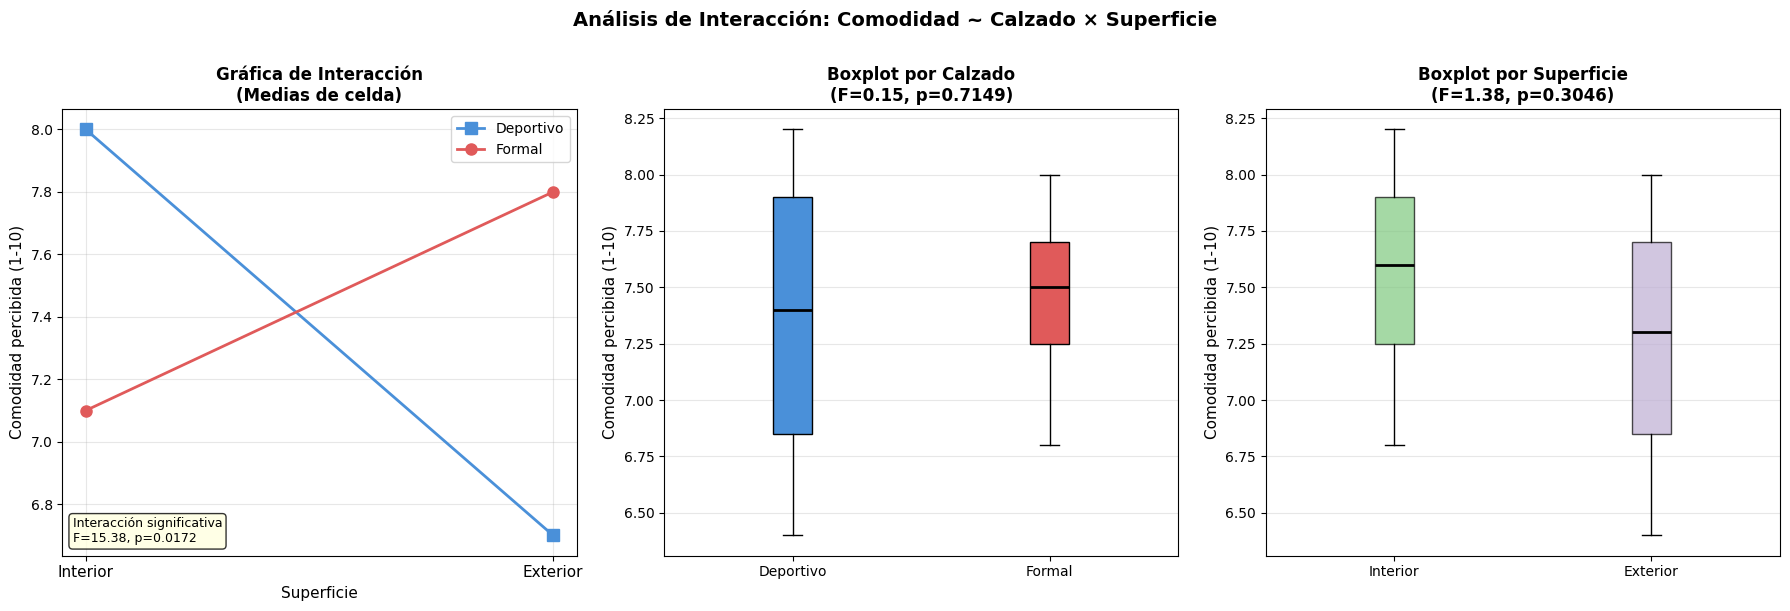

✓ Figura 2 guardada: 'anova_regiones_celdas_calzado_superficie.png'


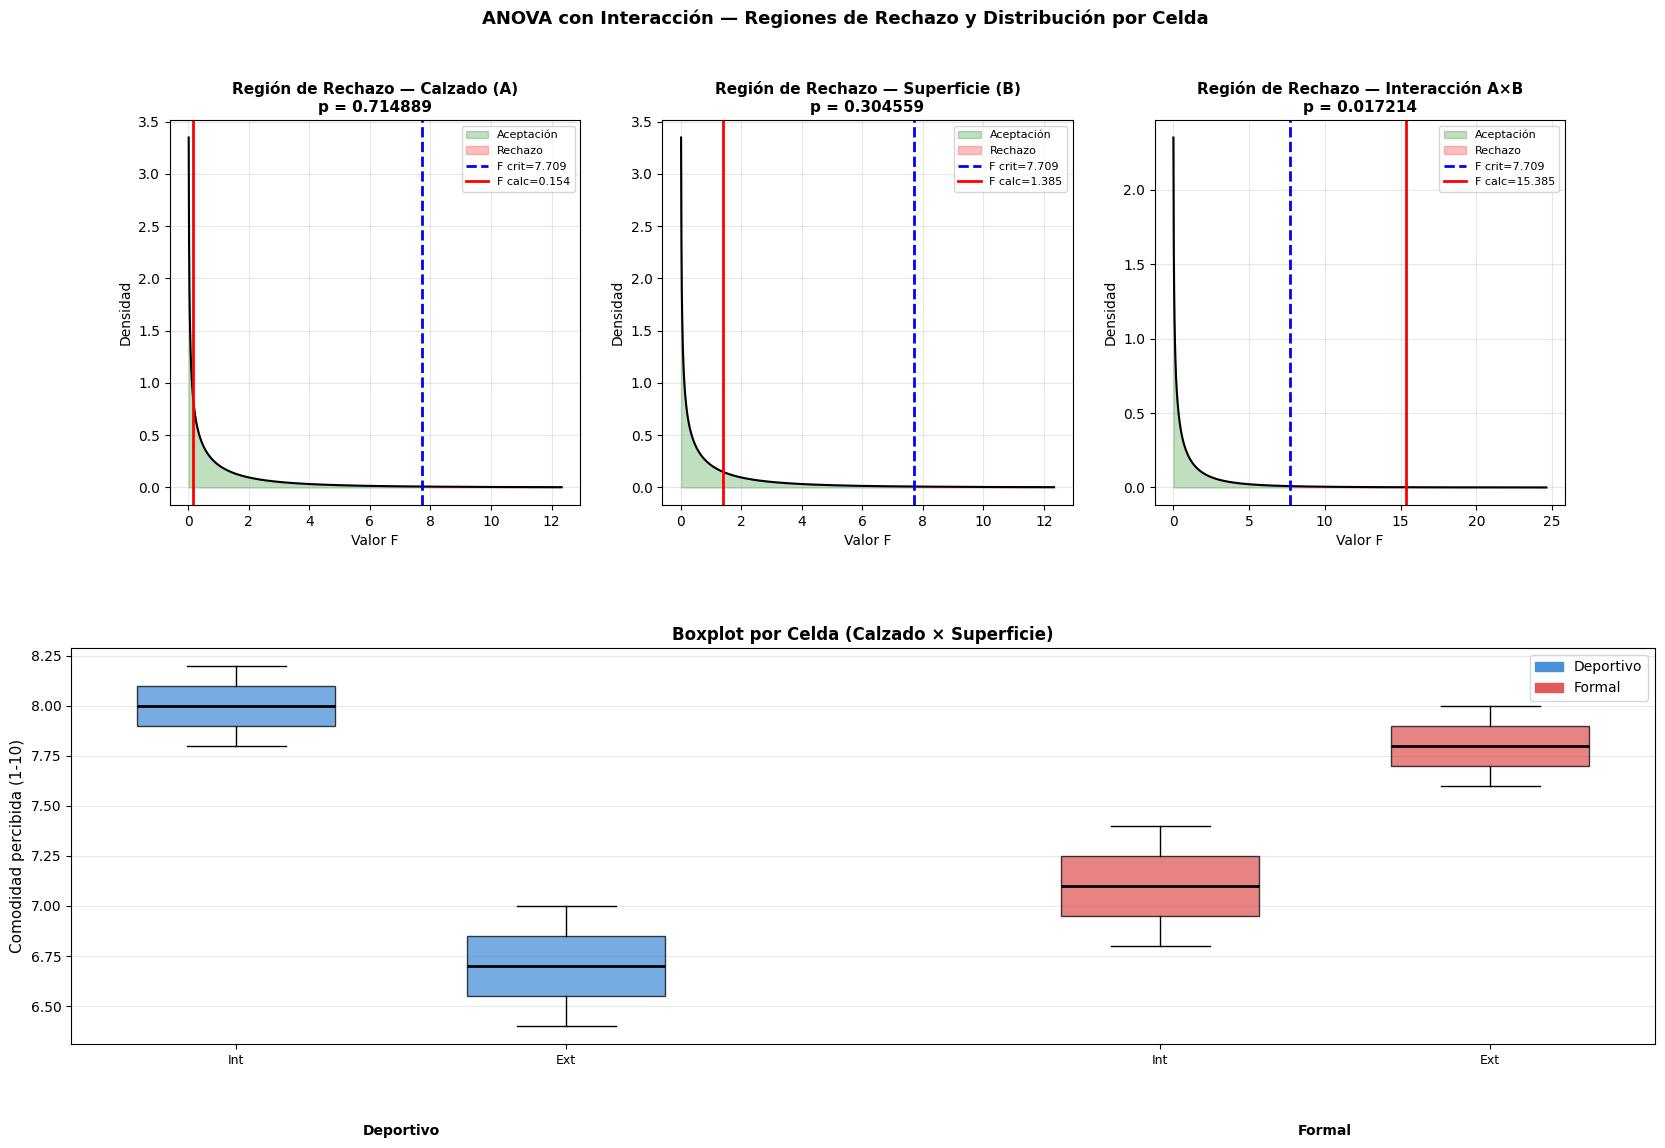

✓ Figura 3 guardada: 'tukey_matrices_interaccion_calzado_superficie.png'


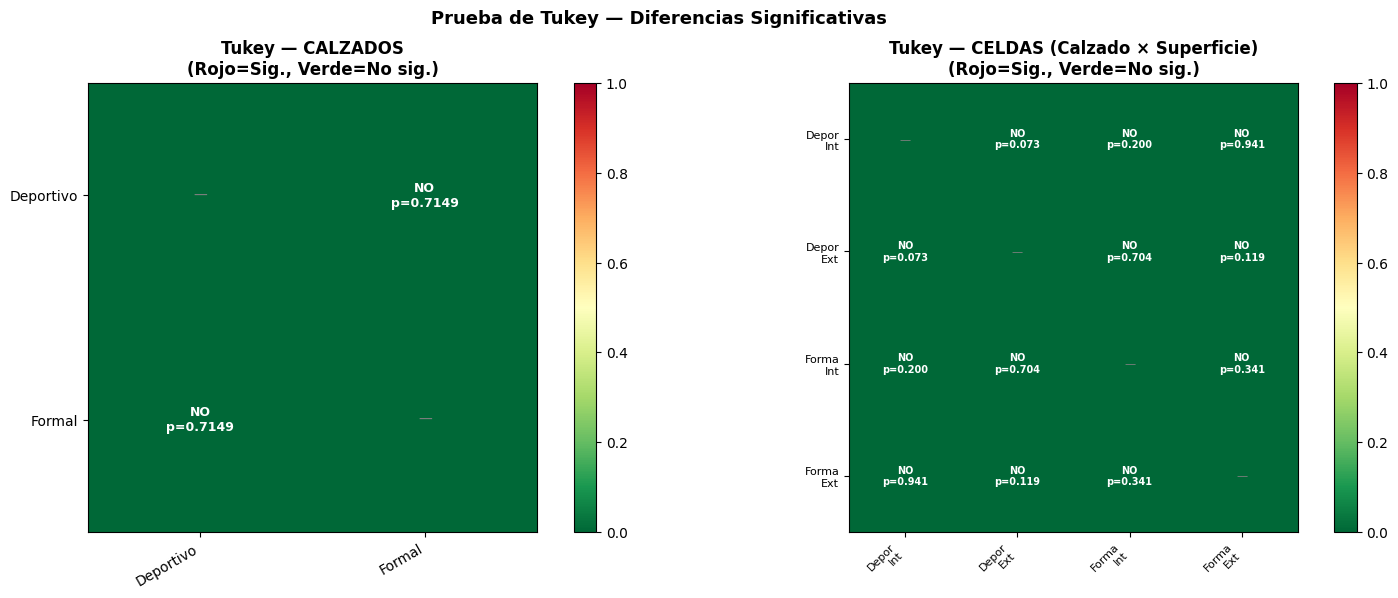


ANÁLISIS COMPLETO FINALIZADO


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

# ============================================================================
# DATOS DEL PROBLEMA
# Comodidad percibida (escala 1-10) por Calzado y Superficie — 2 réplicas por celda
# ============================================================================

calzados    = ['Deportivo', 'Formal'] # Factor A
superficies = ['Interior', 'Exterior']   # Factor B

# datos_raw[calzado][superficie] → lista de 2 observaciones
datos_raw = {
    'Deportivo': {'Interior': [8.2, 7.8],
                  'Exterior': [6.4, 7.0]},
    'Formal': {'Interior': [7.4, 6.8],
               'Exterior': [8.0, 7.6]},
}

num_calzados    = len(calzados)      # niveles factor A (Calzado) = 2
num_superficies = len(superficies)      # niveles factor B (Superficie) = 2
num_replications  = 2                 # réplicas por celda
N  = num_calzados * num_superficies * num_replications # total de observaciones = 8

# Construir array 3-D: Y[i_calzado, j_superficie, k_replication]
Y = np.array([[datos_raw[calz][sup] for sup in superficies] for calz in calzados],
             dtype=float)   # shape (num_calzados, num_superficies, num_replications)

# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================

# Medias de celda (calzado × superficie)
medias_celda = Y.mean(axis=2)                   # (num_calzados, num_superficies)
# Medias marginales
medias_calzado    = Y.mean(axis=(1, 2))             # (num_calzados,) for Factor A
medias_superficie = Y.mean(axis=(0, 2))             # (num_superficies,) for Factor B
media_global   = Y.mean()

df_medias = pd.DataFrame(medias_celda, index=calzados, columns=superficies)
df_medias['Media Calzado'] = medias_calzado

print("=" * 80)
print("DATOS ORIGINALES — COMODIDAD PERCIBIDA")
print("=" * 80)
for calz in calzados:
    print(f"\n  {calz}:")
    for sup in superficies:
        print(f"    {sup}: {datos_raw[calz][sup]}")

print("\n" + "=" * 80)
print("MEDIAS DE CELDA (Calzado × Superficie)")
print("=" * 80)
print(df_medias.round(4).to_string())
print(f"\n  Medias por Superficie: {dict(zip(superficies, medias_superficie.round(4)))}")
print(f"  Media Global    : {media_global:.4f}")

# ============================================================================
# ANOVA DE DOS VÍAS CON INTERACCIÓN
# ============================================================================

# --- Sumas de cuadrados ---
# SST
SST = np.sum((Y - media_global) ** 2)

# SS_A (Calzado)
SS_A = num_superficies * num_replications * np.sum((medias_calzado - media_global) ** 2)

# SS_B (Superficie)
SS_B = num_calzados * num_replications * np.sum((medias_superficie - media_global) ** 2)

# SS_AB (Interacción Calzado × Superficie)
SS_AB = num_replications * np.sum((medias_celda - medias_calzado[:, None]
                                 - medias_superficie[None, :]
                                 + media_global) ** 2)

# SS_E (Error dentro de celdas)
SS_E = np.sum((Y - medias_celda[:, :, None]) ** 2)

# Verificación
assert abs(SST - (SS_A + SS_B + SS_AB + SS_E)) < 1e-6, "¡Error en la partición de SS!"

# --- Grados de libertad ---
gl_A  = num_calzados - 1
gl_B  = num_superficies - 1
gl_AB = (num_calzados - 1) * (num_superficies - 1)
gl_E  = num_calzados * num_superficies * (num_replications - 1)
gl_T  = N - 1

# --- Cuadrados medios ---
CM_A  = SS_A  / gl_A
CM_B  = SS_B  / gl_B
CM_AB = SS_AB / gl_AB
CM_E  = SS_E  / gl_E

# --- Estadísticos F ---
F_A  = CM_A  / CM_E
F_B  = CM_B  / CM_E
F_AB = CM_AB / CM_E

# --- Valores p ---
p_A  = stats.f.sf(F_A,  gl_A,  gl_E)
p_B  = stats.f.sf(F_B,  gl_B,  gl_E)
p_AB = stats.f.sf(F_AB, gl_AB, gl_E)

# --- Valores críticos (α = 0.05) ---
alpha = 0.05
Fc_A  = stats.f.ppf(1 - alpha, gl_A,  gl_E)
Fc_B  = stats.f.ppf(1 - alpha, gl_B,  gl_E)
Fc_AB = stats.f.ppf(1 - alpha, gl_AB, gl_E)

# ============================================================================
# HIPÓTESIS
# ============================================================================

print("\n" + "=" * 80)
print("PLANTEAMIENTO DE HIPÓTESIS")
print("=" * 80)

print("""
FACTOR A — CALZADO:
  H₀: No hay diferencia en la comodidad percibida entre tipos de calzado (Deportivo, Formal)
  H₁: La comodidad percibida difiere entre tipos de calzado

FACTOR B — SUPERFICIE:
  H₀: No hay diferencia en la comodidad percibida entre tipos de superficie (Interior, Exterior)
  H₁: La comodidad percibida difiere entre tipos de superficie

INTERACCIÓN A×B (Calzado × Superficie):
  H₀: El efecto del tipo de superficie sobre la comodidad percibida es el mismo para ambos calzados
      (no existe interacción significativa)
  H₁: El efecto del tipo de superficie sobre la comodidad percibida varía según el tipo de calzado
      (existe interacción significativa)
""")

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("=" * 105)
print("TABLA ANOVA DE DOS VÍAS CON INTERACCIÓN")
print("=" * 105)
print(f"{'Fuente':<20} {'SC':>12} {'gl':>5} {'CM':>12} {'F':>10} {'p-valor':>12} {'F crítico':>12}")
print("-" * 105)
print(f"{'Calzado (A)':<20} {SS_A:>12.4f} {gl_A:>5} {CM_A:>12.4f} {F_A:>10.4f} {p_A:>12.6f} {Fc_A:>12.4f}")
print(f"{'Superficie (B)':<20} {SS_B:>12.4f} {gl_B:>5} {CM_B:>12.4f} {F_B:>10.4f} {p_B:>12.6f} {Fc_B:>12.4f}")
print(f"{'Interacción A×B':<20} {SS_AB:>12.4f} {gl_AB:>5} {CM_AB:>12.4f} {F_AB:>10.4f} {p_AB:>12.6f} {Fc_AB:>12.4f}")
print(f"{'Error':<20} {SS_E:>12.4f} {gl_E:>5} {CM_E:>12.4f}")
print(f"{'Total':<20} {SST:>12.4f} {gl_T:>5}")
print("=" * 105)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

efectos = [
    ("CALZADO (A)",           F_A,  Fc_A,  p_A,  gl_A,  gl_E),
    ("SUPERFICIE (B)",         F_B,  Fc_B,  p_B,  gl_B,  gl_E),
    ("INTERACCIÓN (A×B)",  F_AB, Fc_AB, p_AB, gl_AB, gl_E),
]
for nombre, F_val, Fc, p_val, gl1, gl2 in efectos:
    sig = p_val < alpha
    print(f"\n  {nombre}:")
    print(f"    F calculado = {F_val:.4f}  |  F crítico = {Fc:.4f}  |  p-valor = {p_val:.6f}")
    if sig:
        print(f"    ✓ Efecto SIGNIFICATIVO (p < {alpha}): se rechaza H₀")
    else:
        print(f"    ✘ Efecto NO significativo (p ≥ {alpha}): no se rechaza H₀")

# ============================================================================
# RESPUESTA A LAS PREGUNTAS
# ============================================================================

print("\n" + "=" * 80)
print("RESPUESTAS A LAS PREGUNTAS DEL PROBLEMA")
print("=" * 80)

print("""
a) GRÁFICA DE INTERACCIÓN (ver figura 1):
   Se observa que las líneas de 'Deportivo' y 'Formal' NO son paralelas.
   La comodidad percibida del calzado deportivo es mayor en interiores, mientras que el formal es más cómodo en exteriores.
   Este no paralelismo es evidencia visual de interacción Calzado × Superficie.
""")

if p_AB < alpha:
    print(f"b) ANOVA — INTERACCIÓN: F = {F_AB:.4f}, p = {p_AB:.6f} < 0.05")
    print("   → La interacción Calzado × Superficie ES estadísticamente significativa.")
    print("   El efecto del tipo de superficie sobre la comodidad percibida DEPENDE del tipo de calzado.")
else:
    print(f"b) ANOVA — INTERACCIÓN: F = {F_AB:.4f}, p = {p_AB:.6f} ≥ 0.05")
    print("   → La interacción Calzado × Superficie NO es estadísticamente significativa.")

print(f"""
   CALZADO:    F = {F_A:.4f}, p = {p_A:.6f} {'→ Significativo' if p_A < alpha else '→ No significativo'}
   SUPERFICIE: F = {F_B:.4f}, p = {p_B:.6f} {'→ Significativo' if p_B < alpha else '→ No significativo'}
""")

# ============================================================================
# PRUEBA DE TUKEY
# ============================================================================

print("=" * 80)
print("PRUEBA DE TUKEY (HSD) — COMPARACIONES MÚLTIPLES")
print("=" * 80)

# ------------------------------------------------------------------
# Tukey para CALZADO (factor A, medias marginales)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES PARA CALZADO (medias marginales):")
print("-" * 80)

k_A   = num_calzados
n_A   = num_superficies * num_replications          # observaciones por nivel de A
q_A   = stats.studentized_range.ppf(1 - alpha, k_A, gl_E)
HSD_A = q_A * np.sqrt(CM_E / n_A)

print(f"  q crítico (α={alpha}, k={k_A}, gl_E={gl_E}) = {q_A:.4f}")
print(f"  HSD = {HSD_A:.4f}\n")
print(f"  {'Calzado i':<14} {'Calzado j':<14} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 90)

for i, j in combinations(range(num_calzados), 2):
    dif   = abs(medias_calzado[i] - medias_calzado[j])
    q_obs = dif / np.sqrt(CM_E / n_A)
    p_val = stats.studentized_range.sf(q_obs, k_A, gl_E)
    sig   = "SÍ" if dif > HSD_A else "NO"
    print(f"  {calzados[i]:<14} {calzados[j]:<14} {medias_calzado[i]:>9.2f} {medias_calzado[j]:>9.2f} "
          f"{dif:>8.4f} {q_obs:>8.4f} {p_val:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Tukey para SUPERFICIE (factor B, medias marginales)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES PARA SUPERFICIE (medias marginales):")
print("-" * 80)

k_B   = num_superficies
n_B   = num_calzados * num_replications          # observaciones por nivel de B
q_B   = stats.studentized_range.ppf(1 - alpha, k_B, gl_E)
HSD_B = q_B * np.sqrt(CM_E / n_B)

print(f"  q crítico (α={alpha}, k={k_B}, gl_E={gl_E}) = {q_B:.4f}")
print(f"  HSD = {HSD_B:.4f}\n")
print(f"  {'Superficie i':<12} {'Superficie j':<12} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 82)

for i, j in combinations(range(num_superficies), 2):
    dif   = abs(medias_superficie[i] - medias_superficie[j])
    q_obs = dif / np.sqrt(CM_E / n_B)
    p_val = stats.studentized_range.sf(q_obs, k_B, gl_E)
    sig   = "SÍ" if dif > HSD_B else "NO"
    print(f"  {superficies[i]:<12} {superficies[j]:<12} {medias_superficie[i]:>9.2f} {medias_superficie[j]:>9.2f} "
          f"{dif:>8.4f} {q_obs:>8.4f} {p_val:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Tukey para CELDAS (comparaciones dentro de cada calzado: Interior vs Exterior)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES Interior vs Exterior DENTRO DE CADA CALZADO:")
print("-" * 80)

# Para comparar dos medias de celda se usa num_replications observaciones por celda
q_cel   = stats.studentized_range.ppf(1 - alpha, num_calzados * num_superficies, gl_E)
HSD_cel = q_cel * np.sqrt(CM_E / num_replications)

print(f"  q crítico (α={alpha}, k={num_calzados*num_superficies}, gl_E={gl_E}) = {q_cel:.4f}")
print(f"  HSD = {HSD_cel:.4f}\n")
print(f"  {'Calzado':<14} {'Celd. i':<12} {'Celd. j':<12} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 102)

# Todas las combinaciones de celdas
celdas = [(i, j) for i in range(num_calzados) for j in range(num_superficies)]
for (i1, j1), (i2, j2) in combinations(celdas, 2):
    m1  = medias_celda[i1, j1]
    m2  = medias_celda[i2, j2]
    dif = abs(m1 - m2)
    q_o = dif / np.sqrt(CM_E / num_replications)
    p_v = stats.studentized_range.sf(q_o, num_calzados * num_superficies, gl_E)
    sig = "SÍ" if dif > HSD_cel else "NO"
    lbl1 = f"{calzados[i1][:7]}-{superficies[j1][:3]}"
    lbl2 = f"{calzados[i2][:7]}-{superficies[j2][:3]}"
    print(f"  {calzados[i1]:<14} {lbl1:<12} {lbl2:<12} {m1:>9.2f} {m2:>9.2f} "
          f"{dif:>8.4f} {q_o:>8.4f} {p_v:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Recomendación
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("CONCLUSIÓN E INTERPRETACIÓN DE LOS RESULTADOS:")
print("-" * 80)

if p_AB < alpha:
    print("  ✓ Interacción Calzado × Superficie ES significativa (p < 0.05)."
          " Esto significa que el efecto del tipo de superficie en la comodidad percibida"
          " DEPENDE del tipo de calzado.")
    print("  Por lo tanto, no podemos interpretar los efectos principales de forma aislada.")
    print("  Se debe analizar la interacción específica:")
    print(f"    - Calzado Deportivo: Comodidad Interior ({medias_celda[0,0]:.2f}) vs Exterior ({medias_celda[0,1]:.2f})")
    print(f"    - Calzado Formal: Comodidad Interior ({medias_celda[1,0]:.2f}) vs Exterior ({medias_celda[1,1]:.2f})")
else:
    print("  ✘ Interacción Calzado × Superficie NO es significativa (p ≥ 0.05)."
          " Esto sugiere que el efecto del tipo de superficie en la comodidad percibida"
          " es similar para ambos tipos de calzado, o viceversa.")
    print("  Podemos proceder a interpretar los efectos principales si son significativos.")

if p_A < alpha:
    print("  ✓ Efecto principal de CALZADO ES significativo (p < 0.05)."
          " Hay una diferencia significativa en la comodidad percibida entre los tipos de calzado.")
else:
    print("  ✘ Efecto principal de CALZADO NO es significativo (p ≥ 0.05)."
          " No hay evidencia de que la comodidad percibida difiera entre los tipos de calzado en general.")

if p_B < alpha:
    print("  ✓ Efecto principal de SUPERFICIE ES significativo (p < 0.05)."
          " Hay una diferencia significativa en la comodidad percibida entre los tipos de superficie.")
else:
    print("  ✘ Efecto principal de SUPERFICIE NO es significativo (p ≥ 0.05)."
          " No hay evidencia de que la comodidad percibida difiera entre los tipos de superficie en general.")

print("\n  Considerando la hipótesis inicial de que las diferencias serían pequeñas y no significativas:")
if p_A >= alpha and p_B >= alpha and p_AB >= alpha:
    print("  ✓ Los datos RESPALDAN la hipótesis de no diferencias significativas.")
else:
    print("  ✘ Los datos NO RESPALDAN completamente la hipótesis de no diferencias significativas,")
    print("    ya que se encontraron efectos significativos en al menos uno de los factores o en su interacción.")


# ============================================================================
# FIGURAS
# ============================================================================

COLORES = {'Deportivo': '#4A90D9', 'Formal': '#E05A5A'}
MARKERS = {'Deportivo': 's', 'Formal': 'o'}

# -----------------------------------------------------------------------
# Figura 1 — Gráfica de interacción + Boxplots marginales
# -----------------------------------------------------------------------
fig1, axes = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle('Análisis de Interacción: Comodidad ~ Calzado × Superficie',
              fontsize=14, fontweight='bold', y=1.01)

# --- Panel izquierdo: gráfica de interacción (medias de celda) ---
ax_int = axes[0]
x_pos  = np.arange(num_superficies)
for i, calz in enumerate(calzados):
    ax_int.plot(x_pos, medias_celda[i, :],
                marker=MARKERS[calz], linewidth=2, markersize=8,
                color=COLORES[calz], label=calz)
ax_int.set_xticks(x_pos)
ax_int.set_xticklabels(superficies, fontsize=11)
ax_int.set_xlabel('Superficie', fontsize=11)
ax_int.set_ylabel('Comodidad percibida (1-10)', fontsize=11)
ax_int.set_title('Gráfica de Interacción\n(Medias de celda)', fontsize=12, fontweight='bold')
ax_int.legend(fontsize=10)
ax_int.grid(True, alpha=0.3)

# Anotación de no paralelismo
if p_AB < alpha:
    ax_int.text(0.02, 0.03,
                f"Interacción significativa\nF={F_AB:.2f}, p={p_AB:.4f}",
                transform=ax_int.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# --- Panel central: Boxplot por Calzado ---
ax_box_a = axes[1]
data_box_a = [Y[i, :, :].flatten() for i in range(num_calzados)]
bp1 = ax_box_a.boxplot(data_box_a, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
colors_a = list(COLORES.values()) # Colors for calzados
for patch, col in zip(bp1['boxes'], colors_a):
    patch.set_facecolor(col)
ax_box_a.set_xticks(range(1, num_calzados + 1))
ax_box_a.set_xticklabels(calzados, fontsize=10)
ax_box_a.set_ylabel('Comodidad percibida (1-10)', fontsize=11)
ax_box_a.set_title(f'Boxplot por Calzado\n(F={F_A:.2f}, p={p_A:.4f})',
                   fontsize=12, fontweight='bold')
ax_box_a.grid(True, alpha=0.3, axis='y')

# --- Panel derecho: Boxplot por Superficie ---
ax_box_g = axes[2]
data_box_g = [Y[:, j, :].flatten() for j in range(num_superficies)]
bp2 = ax_box_g.boxplot(data_box_g, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
colors_s = ['#7FC97F', '#BEAED4'] # Colors for superficies
for patch, col in zip(bp2['boxes'], colors_s):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax_box_g.set_xticks(range(1, num_superficies + 1))
ax_box_g.set_xticklabels(superficies, fontsize=10)
ax_box_g.set_ylabel('Comodidad percibida (1-10)', fontsize=11)
ax_box_g.set_title(f'Boxplot por Superficie\n(F={F_B:.2f}, p={p_B:.4f})',
                   fontsize=12, fontweight='bold')
ax_box_g.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('interaccion_boxplots_calzado_superficie.png', dpi=300, bbox_inches='tight')
print("\n✓ Figura 1 guardada: 'interaccion_boxplots_calzado_superficie.png'")
plt.show()

# -----------------------------------------------------------------------
# Figura 2 — Boxplots de celda (Calzado × Superficie) + Región de rechazo × 3
# -----------------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 11))
fig2.suptitle('ANOVA con Interacción — Regiones de Rechazo y Distribución por Celda',
              fontsize=13, fontweight='bold')

# Fila superior: regiones de rechazo para A, B, AB
config_F = [
    ("Calzado (A)", F_A, Fc_A, p_A, gl_A, gl_E),
    ("Superficie (B)", F_B, Fc_B, p_B, gl_B, gl_E),
    ("Interacción A×B", F_AB, Fc_AB, p_AB, gl_AB, gl_E),
]
for col, (nombre, Fval, Fcrít, pval, gl1, gl2) in enumerate(config_F):
    ax = axes2[0, col]
    x_max = max(Fval, Fcrít) * 1.6
    xv    = np.linspace(0, x_max, 1000)
    yv    = stats.f.pdf(xv, gl1, gl2)
    xacc  = xv[xv <= Fcrít];  ax.fill_between(xacc, 0, stats.f.pdf(xacc, gl1, gl2),
                                               alpha=0.25, color='green', label='Aceptación')
    xrej  = xv[xv >= Fcrít];  ax.fill_between(xrej, 0, stats.f.pdf(xrej, gl1, gl2),
                                               alpha=0.25, color='red',   label='Rechazo')
    ax.plot(xv, yv, 'k-', linewidth=1.5)
    ax.axvline(Fcrít, color='blue', linestyle='--', linewidth=2,
               label=f'F crit={Fcrít:.3f}')
    ax.axvline(Fval,  color='red',  linestyle='-',  linewidth=2,
               label=f'F calc={Fval:.3f}')
    ax.set_title(f'Región de Rechazo — {nombre}\np = {pval:.6f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor F'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Fila inferior: boxplot de cada celda (calzado × superficie)
for col in range(3): axes2[1, col].set_visible(False)   # ocultar los tres

# Reemplazar con un subplot 2-D que ocupe toda la fila inferior
gs = fig2.add_gridspec(2, 1, hspace=0.45)   # no afecta lo de arriba — usamos add_axes
ax_celdas = fig2.add_axes([0.07, 0.04, 0.88, 0.36])

posiciones = []
etiquetas  = []
datos_cel  = []
colores_cel = []
offset = 0
tick_posiciones = []
tick_etiquetas  = []

for i, calz in enumerate(calzados):
    centro = offset + num_superficies / 2 - 0.5
    tick_posiciones.append(centro)
    tick_etiquetas.append(calz)
    for j, sup in enumerate(superficies):
        posiciones.append(offset)
        etiquetas.append(f"{sup[:3]}")
        datos_cel.append(Y[i, j, :])
        colores_cel.append(COLORES[calz]) # Usamos el color del calzado
        offset += 1
    offset += 0.8   # separación entre grupos

bps = ax_celdas.boxplot(datos_cel, positions=posiciones, widths=0.6,
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bps['boxes'], colores_cel):
    patch.set_facecolor(col); patch.set_alpha(0.75)

ax_celdas.set_xticks(posiciones)
ax_celdas.set_xticklabels([f"{sup[:3]}" for _ in calzados for sup in superficies], fontsize=9)
for xp, lbl in zip(tick_posiciones, tick_etiquetas):
    ax_celdas.text(xp, ax_celdas.get_ylim()[0] - 0.4, lbl,
                   ha='center', va='top', fontsize=10, fontweight='bold')

ax_celdas.set_ylabel('Comodidad percibida (1-10)', fontsize=11)
ax_celdas.set_title('Boxplot por Celda (Calzado × Superficie)',
                    fontsize=12, fontweight='bold')
ax_celdas.grid(True, alpha=0.3, axis='y')

parches = [mpatches.Patch(color=COLORES[calz], label=calz) for calz in calzados]
ax_celdas.legend(handles=parches, fontsize=10, loc='upper right')

plt.savefig('anova_regiones_celdas_calzado_superficie.png', dpi=300, bbox_inches='tight')
print("✓ Figura 2 guardada: 'anova_regiones_celdas_calzado_superficie.png'")
plt.show()

# -----------------------------------------------------------------------
# Figura 3 — Matrices Tukey (Calzado y Celdas)
# -----------------------------------------------------------------------
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle('Prueba de Tukey — Diferencias Significativas',
              fontsize=13, fontweight='bold')

# Panel izquierdo: matriz calzado × calzado
mat_A = np.zeros((num_calzados, num_calzados))
for i, j in combinations(range(num_calzados), 2):
    dif = abs(medias_calzado[i] - medias_calzado[j])
    mat_A[i, j] = mat_A[j, i] = 1 if dif > HSD_A else 0

im1 = axes3[0].imshow(mat_A, cmap='RdYlGn_r', vmin=0, vmax=1)
axes3[0].set_xticks(range(num_calzados)); axes3[0].set_yticks(range(num_calzados))
axes3[0].set_xticklabels(calzados, rotation=30, ha='right')
axes3[0].set_yticklabels(calzados)
axes3[0].set_title('Tukey — CALZADOS\n(Rojo=Sig., Verde=No sig.)',
                   fontsize=12, fontweight='bold')
for i in range(num_calzados):
    for j in range(num_calzados):
        if i != j:
            dif  = abs(medias_calzado[i] - medias_calzado[j])
            q_ij = dif / np.sqrt(CM_E / n_A)
            p_ij = stats.studentized_range.sf(q_ij, k_A, gl_E)
            axes3[0].text(j, i,
                          f"{'SÍ' if mat_A[i,j] else 'NO'}\np={p_ij:.4f}",
                          ha='center', va='center',
                          color='white', fontweight='bold', fontsize=9)
        else:
            axes3[0].text(j, i, '—', ha='center', va='center',
                          color='gray', fontsize=10)
plt.colorbar(im1, ax=axes3[0])

# Panel derecho: matriz celda × celda
n_celdas   = num_calzados * num_superficies
etiq_cel   = [f"{calz[:5]}\n{sup[:3]}" for calz in calzados for sup in superficies]
medias_vec = medias_celda.flatten()          # orden: (Deportivo-Int, Deportivo-Ext, Formal-Int, Formal-Ext)
mat_C = np.zeros((n_celdas, n_celdas))
for ci, cj in combinations(range(n_celdas), 2):
    dif = abs(medias_vec[ci] - medias_vec[cj])
    mat_C[ci, cj] = mat_C[cj, ci] = 1 if dif > HSD_cel else 0

im2 = axes3[1].imshow(mat_C, cmap='RdYlGn_r', vmin=0, vmax=1)
axes3[1].set_xticks(range(n_celdas)); axes3[1].set_yticks(range(n_celdas))
axes3[1].set_xticklabels(etiq_cel, rotation=45, ha='right', fontsize=8)
axes3[1].set_yticklabels(etiq_cel, fontsize=8)
axes3[1].set_title('Tukey — CELDAS (Calzado × Superficie)\n(Rojo=Sig., Verde=No sig.)',
                   fontsize=12, fontweight='bold')
for ci in range(n_celdas):
    for cj in range(n_celdas):
        if ci != cj:
            dif  = abs(medias_vec[ci] - medias_vec[cj])
            q_ij = dif / np.sqrt(CM_E / num_replications)
            p_ij = stats.studentized_range.sf(q_ij, n_celdas, gl_E)
            axes3[1].text(cj, ci,
                          f"{'SÍ' if mat_C[ci,cj] else 'NO'}\np={p_ij:.3f}",
                          ha='center', va='center',
                          color='white', fontweight='bold', fontsize=7)
        else:
            axes3[1].text(cj, ci, '—', ha='center', va='center',
                          color='gray', fontsize=8)
plt.colorbar(im2, ax=axes3[1])

plt.tight_layout()
plt.savefig('tukey_matrices_interaccion_calzado_superficie.png', dpi=300, bbox_inches='tight')
print("✓ Figura 3 guardada: 'tukey_matrices_interaccion_calzado_superficie.png'")
plt.show()

print("\n" + "=" * 80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("=" * 80)


ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Velocidad de la Cinta vs. Unidades Producidas

Datos cargados: 10 observaciones
Variable independiente (X): Velocidad de la cinta (m/min)
Variable dependiente (Y): Unidades producidas por hora
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


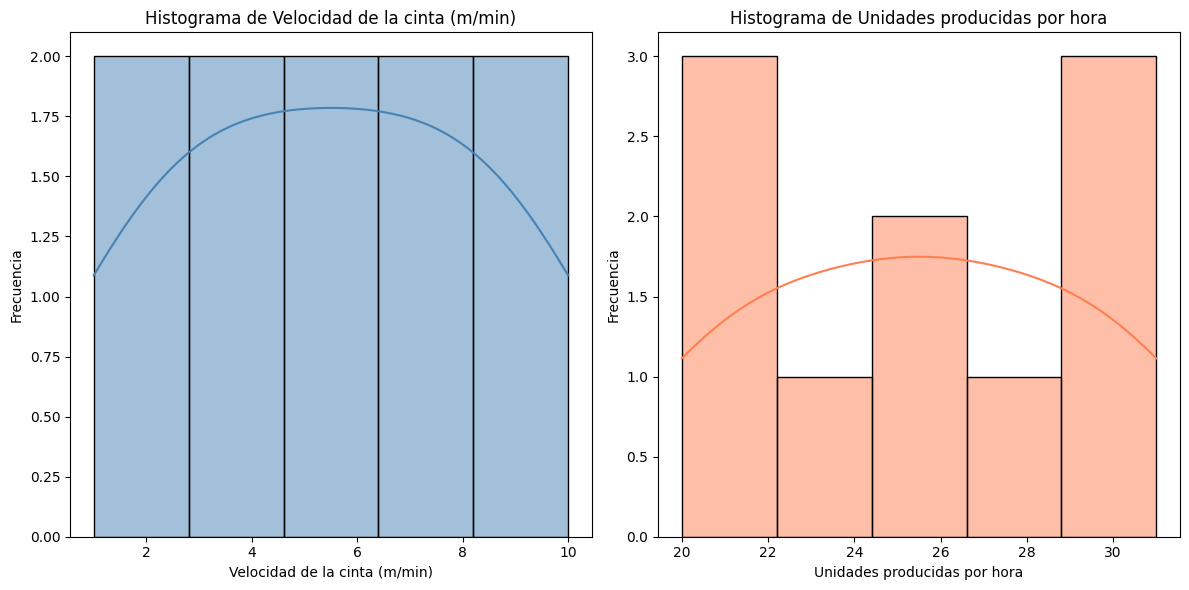

------------------------------
Generating Scatter Plot...


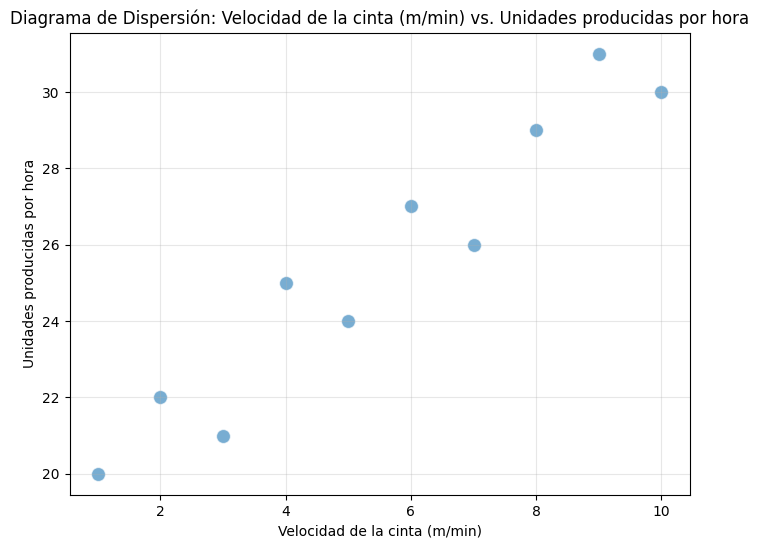

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Velocidad de la cinta (m/min)': Statistics=0.970, p-value=0.892
Shapiro-Wilk test for 'Unidades producidas por hora': Statistics=0.958, p-value=0.761

Interpretation of normality test results:
✓ The 'Velocidad de la cinta (m/min)' variable appears to be normally distributed (p > 0.05).
✓ The 'Unidades producidas por hora' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.9589
Kendall correlation coefficient: 0.8222
Spearman correlation coefficient: 0.9515
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.9589) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

H

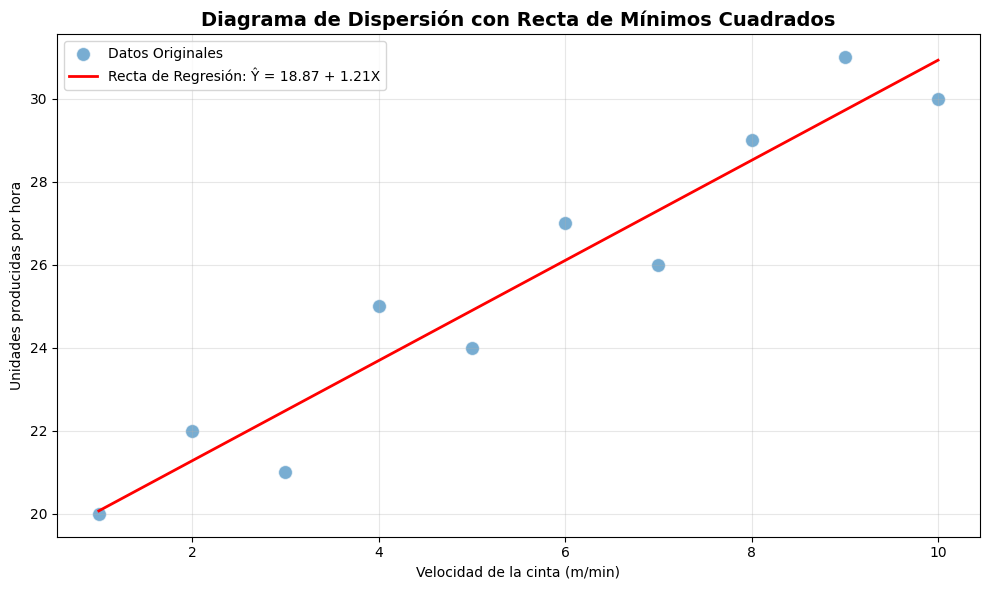


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 10.4970
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 1.1455

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 82.5000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.1261

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (1.2061 - 0) / 0.1261
   t calculado = 9.5633

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 8
   Valor crítico (t_0.05,8) = 1.8595
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (9.5633) > t crítico (1.8595)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferente de 

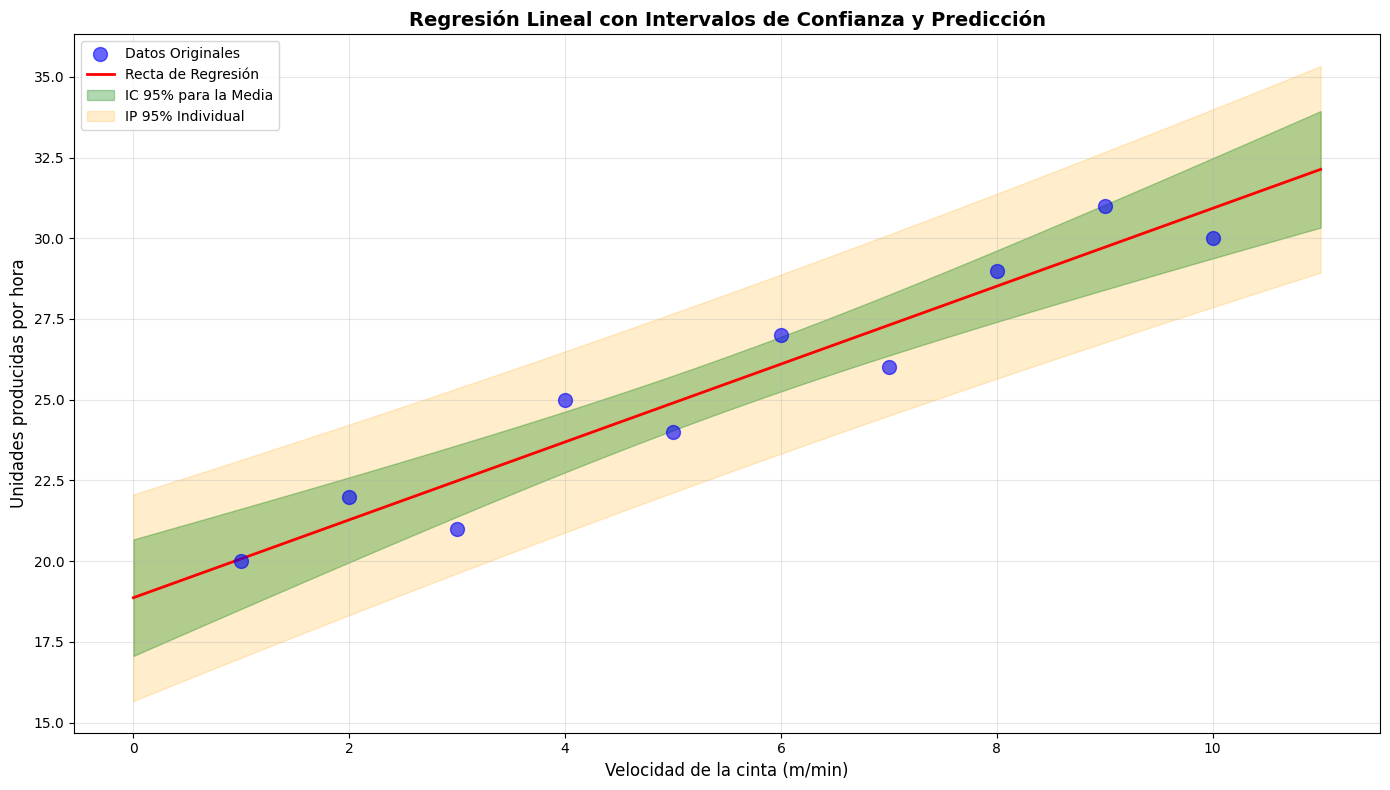

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

X        Y        ŷ        Residuo    Res. Std. 
------------------------------------------------------
1.0      20.0     20.07    -0.07      -0.06     
2.0      22.0     21.28    0.72       0.63      
3.0      21.0     22.48    -1.48      -1.30     
4.0      25.0     23.69    1.31       1.14      
5.0      24.0     24.90    -0.90      -0.78     
6.0      27.0     26.10    0.90       0.78      
7.0      26.0     27.31    -1.31      -1.14     
8.0      29.0     28.52    0.48       0.42      
9.0      31.0     29.72    1.28       1.12      
10.0     30.0     30.93    -0.93      -0.81     

Estadísticas de los Residuos:
  Media de residuos: -0.0000 (debe ser ≈ 0)
  Desviación estándar: 1.0800
  Residuo mínimo: -1.4848
  Residuo máximo: 1.3091


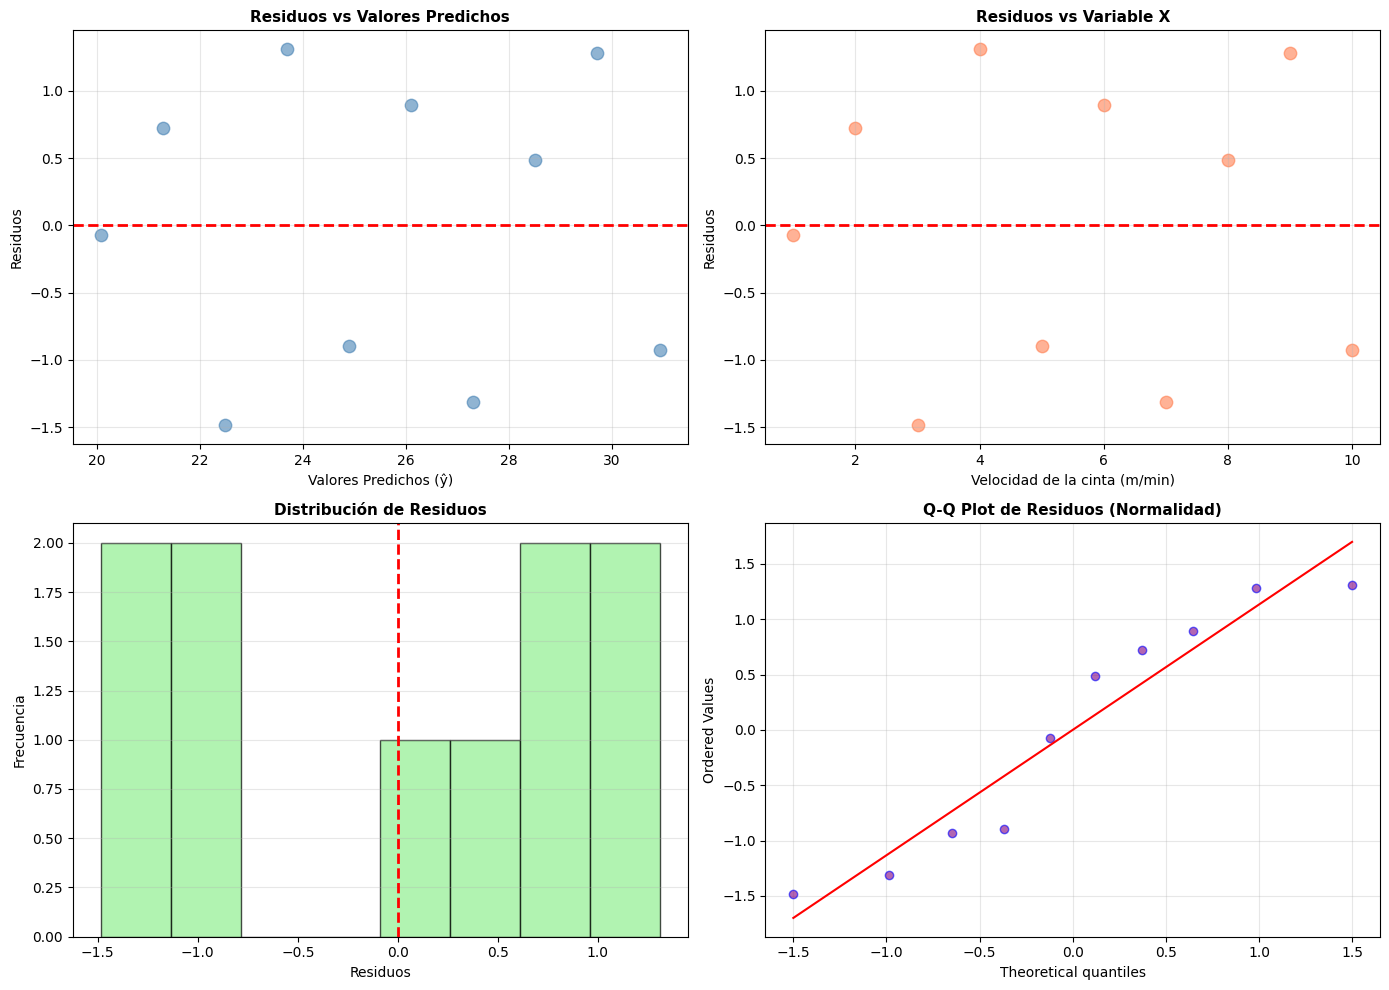


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.8957
  Valor p = 0.1965
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Velocidad de la cinta (m/min): p-value = 0.8924
     ✓ Distribución normal
   • Unidades producidas por hora: p-value = 0.7615
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.1965
     ✓ Distribución normal



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VELOCIDAD DE LA CINTA Y UNIDADES PRODUCIDAS) ---
data = {
    'Velocidad de la cinta (m/min)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Unidades producidas por hora': [20, 22, 21, 25, 24, 27, 26, 29, 31, 30]
}
df = pd.DataFrame(data)

variable_x = 'Velocidad de la cinta (m/min)'
variable_y = 'Unidades producidas por hora'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Velocidad de la Cinta vs. Unidades Producidas")
print("=" * 70)
print(f"\nDatos cargados: {n} observaciones")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el {variable_x} tiene un efecto significativo POSITIVO sobre
    el {variable_y}.

    En términos prácticos: Por cada unidad adicional de {variable_x}, se espera un
    incremento de {b1:.4f} {variable_y}, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el {variable_x}
    tenga un efecto significativo sobre el {variable_y}.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el {variable_y}            │")
print(f"│  puede ser explicada por el {variable_x}.                     │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [df[variable_x].min(), df[variable_x].mean(), df[variable_x].median(), df[variable_x].max()]  # Ejemplos de velocidad de cinta

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de {variable_y}:\n")
print(f"{'X (' + variable_x + ')':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15.1f} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se tiene X {variable_x},")
print(f"la MEDIA de {variable_y} estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para {variable_y} INDIVIDUALES:\n")
print(f"{'X (' + variable_x + ')':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15.1f} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se tiene X {variable_x},")
print(f"una observación INDIVIDUAL de {variable_y} estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 1, df[variable_x].max() + 1, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 54)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Observaciones con residuos atípicos (X, Y):")
    for idx, row in outliers.iterrows():
        print(f"     - ({row[variable_x]}, {row[variable_y]}): residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} {variable_y} cuando {variable_x} es 0
   • Por cada unidad adicional de {variable_x}, aumentan {b1:.4f} {variable_y}

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} {variable_y}

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión' if abs(r) > 0.6 else '⚠ Revisar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El {variable_x} es un predictor SIGNIFICATIVO del
   {variable_y}. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir {variable_y} futuras basadas en {variable_x} planificada
   • Establecer objetivos de {variable_x} para alcanzar metas de {variable_y}

   Recomendación: IMPLEMENTAR este modelo en la planificación.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre {variable_x} y {variable_y}, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)